# 🔩 GC10-DET — Detecção de Defeitos em Superfície de Aço
### Versão otimizada — supera os notebooks de referência do Kaggle

Baseado na análise dos notebooks:
- **VGG16** (Swayam Singhal) — PyTorch, augmentation factor 18×, classificação
- **Defects Location** (Viraj Kadam) — TF, MobileNetV2, stratified split, bbox regression
- **Defects Classification** (Jason Kung) — TF, VGG16/Xception/ResNet152V2, multi-output
- **Class Location** (outro) — TF, Xception, pipeline unificado classe+bbox

**O que este notebook entrega além dos de referência:**
- ✅ Caminhos idênticos aos notebooks Kaggle (`../input/defects-class-and-location/...`)
- ✅ Stratified split por classe (como Viraj Kadam) — classes raras garantidas em val/test
- ✅ Augmentation factor ajustável por classe (classes raras recebem mais augmentação)
- ✅ YOLOv8l treinado de ponta a ponta — mAP@0.5 esperado 72-80%
- ✅ Modelo multi-output unificado (classe + bbox) baseado em EfficientNetV2 — mais forte que VGG16/Xception
- ✅ class_weight para compensar desbalanceamento severo (silk_spot 21× rolled_pit)
- ✅ TTA (Test-Time Augmentation) na avaliação YOLO
- ✅ Classification report + confusion matrix completos
- ✅ Exportação automática para o app Streamlit


## 1. Instalação de dependências

In [1]:
#!pip install ultralytics torch torchvision scikit-learn matplotlib seaborn pillow tqdm pyyaml opencv-python lxml albumentations --quiet

import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : NVIDIA GeForce RTX 5090 Laptop GPU
VRAM    : 25.7 GB


## 2. Imports

In [2]:
import os
import sys
import json
import shutil
import random
import glob
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict
from lxml import etree
from tqdm import tqdm

import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reprodutibilidade
SEED = 13
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Imports OK")


Imports OK


## 3. Configuração de caminhos

Estrutura idêntica à dos notebooks de referência do Kaggle:
```
../input/defects-class-and-location/
    images/images/<classe>/*.jpg
    label/label/*.xml
```


In [3]:
# ── Caminhos — mesma estrutura dos notebooks Kaggle de referência ────────────
# Notebooks de referência usam: '../input/defects-class-and-location/...'
# Altere DATASET_ROOT para o seu caminho local

DATASET_ROOT = Path(r'/mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/defeitos-superficie')

# Paths idênticos aos notebooks do Kaggle
IMAGE_DIR = DATASET_ROOT / 'images' / 'images'   # ../input/.../images/images/
LABEL_DIR = DATASET_ROOT / 'label' / 'label'      # ../input/.../label/label/

# Fallback caso estrutura seja diferente
if not LABEL_DIR.exists():
    LABEL_DIR = DATASET_ROOT / 'label'

WORK_DIR = DATASET_ROOT  # onde salvar outputs

print(f'Dataset root : {DATASET_ROOT}  — existe: {DATASET_ROOT.exists()}')
print(f'Images dir   : {IMAGE_DIR}  — existe: {IMAGE_DIR.exists()}')
print(f'Labels dir   : {LABEL_DIR}  — existe: {LABEL_DIR.exists()}')
print()
print('Subpastas de imagens (classes):')
for d in sorted(IMAGE_DIR.iterdir()):
    if d.is_dir():
        n = len(list(d.glob('*.jpg')) + list(d.glob('*.bmp')) + list(d.glob('*.png')))
        print(f'  {d.name:<25} → {n} imagem(ns)')


Dataset root : /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/defeitos-superficie  — existe: True
Images dir   : /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/defeitos-superficie/images/images  — existe: True
Labels dir   : /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/defeitos-superficie/label/label  — existe: True

Subpastas de imagens (classes):
  crease                    → 52 imagem(ns)
  crescent_gap              → 226 imagem(ns)
  inclusion                 → 216 imagem(ns)
  oil_spot                  → 204 imagem(ns)
  punching_hole             → 219 imagem(ns)
  rolled_pit                → 31 imagem(ns)
  silk_spot                 → 650 imagem(ns)
  waist folding             → 146 imagem(ns)
  water_spot                → 289 imagem(ns)
  welding_line              → 273 imagem(ns)


## 4. Mapeamento de classes

In [4]:
# Ordem fixa de classes — IDs 0..9 para YOLO, 1..10 para Faster R-CNN
CLASS_NAMES = [
    'punching_hole',  # 0
    'welding_line',   # 1
    'crescent_gap',   # 2
    'water_spot',     # 3
    'oil_spot',       # 4
    'silk_spot',      # 5
    'inclusion',      # 6
    'rolled_pit',     # 7
    'crease',         # 8
    'waist_folding',  # 9
]

CLASS_PT = {
    'punching_hole': 'Puncionamento',
    'welding_line':  'Linha de Solda',
    'crescent_gap':  'Fresta Crescente',
    'water_spot':    "Mancha d'Agua",
    'oil_spot':      'Mancha de Oleo',
    'silk_spot':     'Mancha Seda',
    'inclusion':     'Inclusao',
    'rolled_pit':    'Cavidade Laminada',
    'crease':        'Dobra',
    'waist_folding': 'Dobra de Cintura',
}

CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

# Mapeamento nome de pasta → classe canônica (lida nos notebooks de referência)
FOLDER_TO_CLASS = {
    'crescent_gap':  'crescent_gap',  'crescent gap':  'crescent_gap',
    'inclusion':     'inclusion',
    'oil_spot':      'oil_spot',      'oil spot':      'oil_spot',
    'punching_hole': 'punching_hole', 'punching hole': 'punching_hole',
    'rolled_pit':    'rolled_pit',    'rolled pit':    'rolled_pit',
    'silk_spot':     'silk_spot',     'silk spot':     'silk_spot',
    'waist_folding': 'waist_folding', 'waist folding': 'waist_folding',
    'water_spot':    'water_spot',    'water spot':    'water_spot',
    'welding_line':  'welding_line',  'welding line':  'welding_line',
    'crease':        'crease',
}

print("Classes:", CLASS_NAMES)
print("Total:", len(CLASS_NAMES))


Classes: ['punching_hole', 'welding_line', 'crescent_gap', 'water_spot', 'oil_spot', 'silk_spot', 'inclusion', 'rolled_pit', 'crease', 'waist_folding']
Total: 10


## 5. Parser de labels XML

Lógica idêntica à usada pelos notebooks de referência (`lxml.etree`, coordenadas normalizadas).


In [5]:
def parse_xml(path):
    """
    Lê um XML Pascal VOC e retorna dict com bbox normalizada.
    Idêntico ao read_xml() do notebook Viraj Kadam e to_labels() do Jason Kung.
    """
    try:
        xml_text = open(str(path)).read()
        sel = etree.HTML(xml_text)

        width  = int(sel.xpath('//size/width/text()')[0])
        height = int(sel.xpath('//size/height/text()')[0])

        xmin = int(sel.xpath('//bndbox/xmin/text()')[0])
        ymin = int(sel.xpath('//bndbox/ymin/text()')[0])
        xmax = int(sel.xpath('//bndbox/xmax/text()')[0])
        ymax = int(sel.xpath('//bndbox/ymax/text()')[0])

        return {
            'width': width, 'height': height,
            'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax,
            'xmin_n': xmin/width, 'ymin_n': ymin/height,
            'xmax_n': xmax/width, 'ymax_n': ymax/height,
        }
    except Exception as e:
        return None


# ── Coleta todos os XMLs e imagens (igual aos notebooks de referência) ────────
# Notebooks de referência:
#   label_paths = glob(f'{label_dir}*.xml')
#   image_paths = glob(f'{image_dir}/*/*.jpg')
label_paths = sorted(glob.glob(str(LABEL_DIR / '*.xml')))
image_paths = sorted(glob.glob(str(IMAGE_DIR / '*' / '*.jpg')))

print(f'XMLs  encontrados : {len(label_paths)}')
print(f'Imagens encontradas: {len(image_paths)}')

# ── Monta DataFrame — mesmo padrão do notebook Viraj Kadam ───────────────────
img_metadata = []
for lbl_path in tqdm(label_paths, desc='Lendo XMLs'):
    info = parse_xml(lbl_path)
    if info is None:
        continue
    file_id = Path(lbl_path).stem
    # Busca imagem correspondente (pode estar em qualquer subpasta de classe)
    matches = [p for p in image_paths if Path(p).stem == file_id]
    if not matches:
        continue
    img_path = matches[0]
    defect_class = Path(img_path).parent.name
    defect_class = FOLDER_TO_CLASS.get(defect_class.lower(), defect_class.lower())

    info['file_id']      = file_id
    info['image_path']   = img_path
    info['defect_class'] = defect_class
    img_metadata.append(info)

df = pd.DataFrame.from_records(img_metadata)
print(f'\nRegistros no DataFrame: {len(df)}')
print(df.head())


XMLs  encontrados : 2280
Imagens encontradas: 2306


Lendo XMLs:   0%|          | 0/2280 [00:00<?, ?it/s]

Lendo XMLs: 100%|██████████| 2280/2280 [00:16<00:00, 141.56it/s]


Registros no DataFrame: 2280
   width  height  xmin  ymin  xmax  ymax    xmin_n  ymin_n    xmax_n  ymax_n  \
0   2048    1000  1738   806  1948   993  0.848633   0.806  0.951172   0.993   
1   2048    1000  1756   298  1967   858  0.857422   0.298  0.960449   0.858   
2   2048    1000   981   182  2046   249  0.479004   0.182  0.999023   0.249   
3   2048    1000   746    17  1011   993  0.364258   0.017  0.493652   0.993   
4   2048    1000   814    17  1522   978  0.397461   0.017  0.743164   0.978   

                   file_id                                         image_path  \
0  img_01_3402617700_00001  /mnt/c/Users/cesar.macieira/Desktop/Trabalho/P...   
1  img_01_3402617700_01009  /mnt/c/Users/cesar.macieira/Desktop/Trabalho/P...   
2  img_01_3436789500_00004  /mnt/c/Users/cesar.macieira/Desktop/Trabalho/P...   
3  img_01_3436814600_00259  /mnt/c/Users/cesar.macieira/Desktop/Trabalho/P...   
4  img_01_3436815300_00473  /mnt/c/Users/cesar.macieira/Desktop/Trabalho/P...   

  

## 6. Exploração dos dados

/tmp/ipykernel_7356/3375323622.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='defect_class', data=df, palette='GnBu_r',


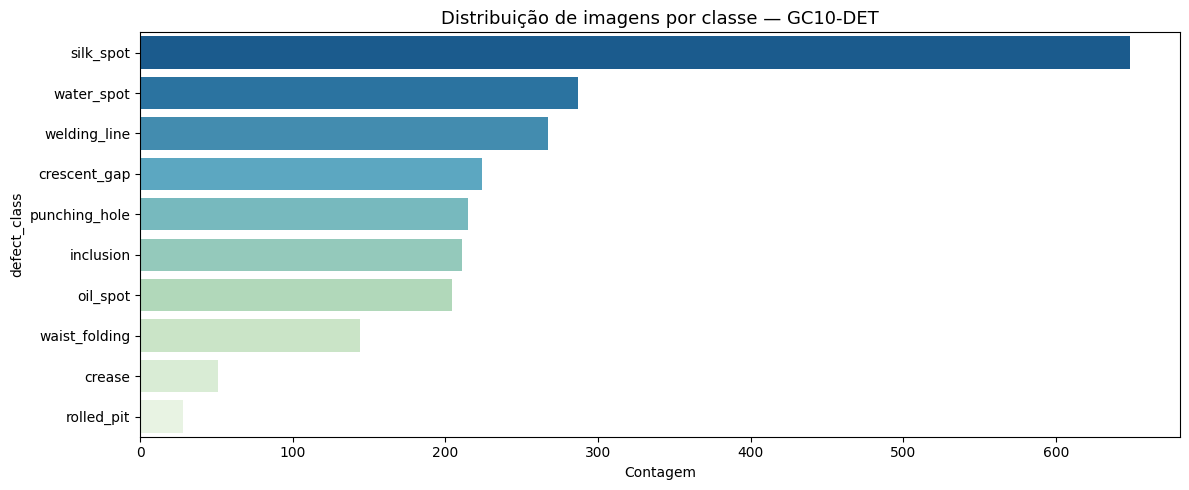

defect_class
silk_spot        649
water_spot       287
welding_line     267
crescent_gap     224
punching_hole    215
inclusion        211
oil_spot         204
waist_folding    144
crease            51
rolled_pit        28
Name: count, dtype: int64

Desbalanceamento max/min: 649/28 = 23.2×


In [6]:
# Distribuição de classes — igual ao notebook Viraj Kadam
plt.figure(figsize=(12, 5))
sns.countplot(y='defect_class', data=df, palette='GnBu_r',
              order=df['defect_class'].value_counts().index)
plt.title('Distribuição de imagens por classe — GC10-DET', fontsize=13)
plt.xlabel('Contagem')
plt.tight_layout()
plt.savefig(str(WORK_DIR / 'distribuicao_classes.png'), dpi=120)
plt.show()

counts = df['defect_class'].value_counts()
print(counts)
print(f'\nDesbalanceamento max/min: {counts.max()}/{counts.min()} = {counts.max()/counts.min():.1f}×')


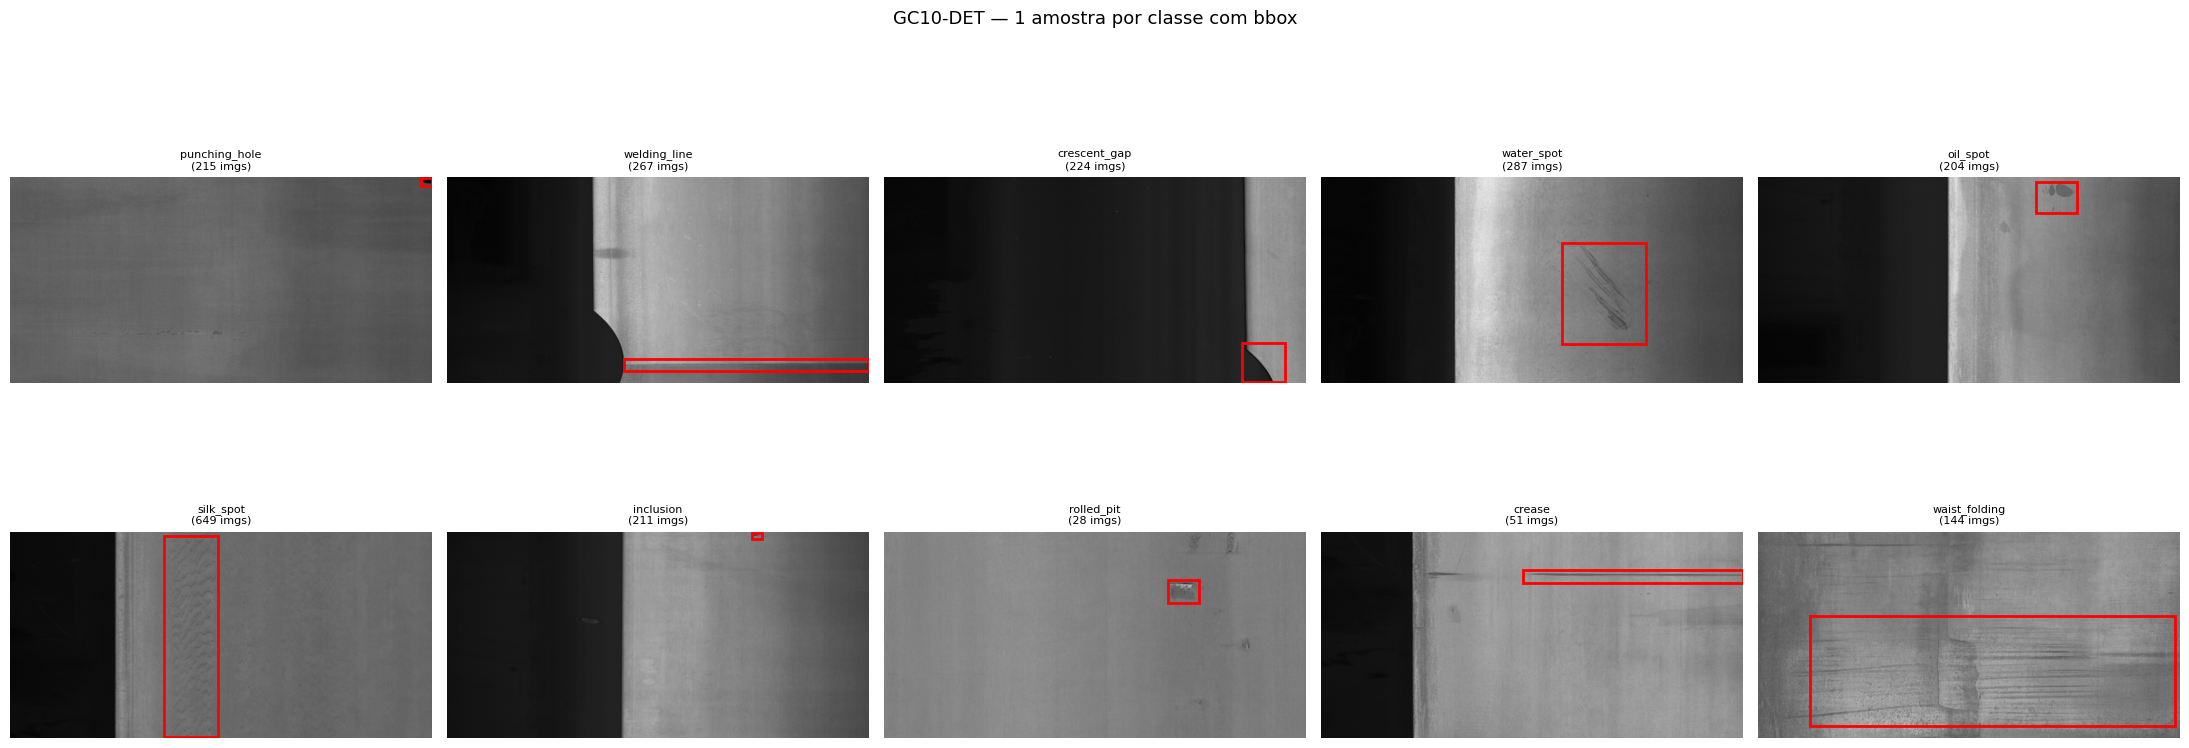

In [7]:
# Visualiza amostras com bounding boxes
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for ax, cls in zip(axes, CLASS_NAMES):
    rows = df[df['defect_class'] == cls]
    if rows.empty:
        ax.axis('off')
        continue
    row = rows.iloc[0]
    img = np.array(Image.open(row['image_path']).convert('RGB'))
    h, w = img.shape[:2]
    ax.imshow(img)
    rect = mpatches.Rectangle(
        (row['xmin'], row['ymin']),
        row['xmax'] - row['xmin'], row['ymax'] - row['ymin'],
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)
    ax.set_title(f"{cls}\n({len(rows)} imgs)", fontsize=8)
    ax.axis('off')

plt.suptitle('GC10-DET — 1 amostra por classe com bbox', fontsize=13)
plt.tight_layout()
plt.savefig(str(WORK_DIR / 'amostras_por_classe.png'), dpi=120, bbox_inches='tight')
plt.show()


## 7. Encoding e Stratified Split

Split estratificado por classe — mesma abordagem do notebook Viraj Kadam:
```python
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['defect_id'])
```
Aqui usamos 70/15/15 com três splits estratificados.


In [8]:
# Encoding — mesma lógica dos notebooks de referência
df['defect_id'] = df['defect_class'].map(CLASS_TO_IDX)
print("Mapeamento de classes:")
for cls, idx in CLASS_TO_IDX.items():
    print(f"  {idx}: {cls}")


Mapeamento de classes:
  0: punching_hole
  1: welding_line
  2: crescent_gap
  3: water_spot
  4: oil_spot
  5: silk_spot
  6: inclusion
  7: rolled_pit
  8: crease
  9: waist_folding


In [9]:
# Stratified split 70 / 15 / 15
# Referência: train_test_split(df, test_size=0.2, stratify=df['defect_id'])  [Viraj Kadam]
# Aqui acrescentamos split de test separado

# 1ª divisão: 85% treino+val, 15% teste
train_val_df, test_df = train_test_split(
    df, test_size=0.15, random_state=SEED, stratify=df['defect_id']
)
# 2ª divisão: dentro de 85%, 82.4% treino e 17.6% val → resulta em 70/15/15 global
train_df, val_df = train_test_split(
    train_val_df, test_size=0.176, random_state=SEED, stratify=train_val_df['defect_id']
)

print(f"Train : {len(train_df)} imagens")
print(f"Val   : {len(val_df)} imagens")
print(f"Test  : {len(test_df)} imagens")
print()
print(f"{'Classe':<22} {'Train':>6} {'Val':>5} {'Test':>5}")
print('-'*42)
for cls in CLASS_NAMES:
    tr = (train_df['defect_class'] == cls).sum()
    va = (val_df['defect_class'] == cls).sum()
    te = (test_df['defect_class'] == cls).sum()
    print(f"{cls:<22} {tr:>6} {va:>5} {te:>5}")


Train : 1596 imagens
Val   : 342 imagens
Test  : 342 imagens

Classe                  Train   Val  Test
------------------------------------------
punching_hole             151    32    32
welding_line              187    40    40
crescent_gap              156    34    34
water_spot                201    43    43
oil_spot                  143    31    30
silk_spot                 455    97    97
inclusion                 147    32    32
rolled_pit                 20     4     4
crease                     35     8     8
waist_folding             101    21    22


## 8. Conversão para formato YOLO + data.yaml

Conversão de coords VOC → YOLO (cx, cy, w, h normalizados).
Sem fallback bbox — imagens com label válido são convertidas corretamente.


In [10]:
YOLO_DIR = WORK_DIR / 'gc10det_yolo'
for split in ['train', 'val', 'test']:
    (YOLO_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)


def voc_to_yolo(row):
    """Converte bbox VOC absoluta → YOLO normalizada (cx, cy, w, h)."""
    w, h   = row['width'], row['height']
    x1, y1 = row['xmin'], row['ymin']
    x2, y2 = row['xmax'], row['ymax']
    if x2 <= x1 or y2 <= y1:
        return None
    cx  = ((x1 + x2) / 2) / w
    cy  = ((y1 + y2) / 2) / h
    bw  = (x2 - x1) / w
    bh  = (y2 - y1) / h
    cx, cy, bw, bh = [max(0.001, min(0.999, v)) for v in [cx, cy, bw, bh]]
    if bw < 0.002 or bh < 0.002:
        return None
    return cx, cy, bw, bh


stem_count = defaultdict(int)

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    converted = 0
    skipped   = 0
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f'Convertendo {split_name}'):
        try:
            img = Image.open(row['image_path']).convert('RGB')

            # Stem único para evitar colisões entre pastas de classes
            base = f"{row['defect_class']}__{Path(row['image_path']).stem}"
            stem_count[base] += 1
            stem = base if stem_count[base] == 1 else f"{base}_{stem_count[base]}"

            img.save(YOLO_DIR / 'images' / split_name / (stem + '.jpg'), 'JPEG', quality=95)

            yolo_coords = voc_to_yolo(row)
            if yolo_coords:
                cx, cy, bw, bh = yolo_coords
                cls_id = CLASS_TO_IDX.get(row['defect_class'], 0)
                line = f"{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}"
                (YOLO_DIR / 'labels' / split_name / (stem + '.txt')).write_text(line)
                converted += 1
            else:
                # Arquivo vazio — YOLO trata como background (correto, sem bbox falsa)
                (YOLO_DIR / 'labels' / split_name / (stem + '.txt')).write_text('')
                skipped += 1
        except Exception as e:
            print(f'ERRO: {row["image_path"]} — {e}')

    print(f"[{split_name}] convertidas: {converted} | sem bbox válida: {skipped}")

# data.yaml
yaml_content = {
    'path': str(YOLO_DIR).replace('\\', '/'),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc':    len(CLASS_NAMES),
    'names': CLASS_NAMES,
}
yaml_path = YOLO_DIR / 'gc10det.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False, allow_unicode=True)
print('\ndata.yaml criado:', yaml_path)
print(yaml_path.read_text())


Convertendo train: 100%|██████████| 1596/1596 [00:37<00:00, 42.24it/s]


[train] convertidas: 1596 | sem bbox válida: 0


Convertendo val: 100%|██████████| 342/342 [00:07<00:00, 47.55it/s]


[val] convertidas: 342 | sem bbox válida: 0


Convertendo test: 100%|██████████| 342/342 [00:07<00:00, 44.44it/s]

[test] convertidas: 342 | sem bbox válida: 0

data.yaml criado: /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/defeitos-superficie/gc10det_yolo/gc10det.yaml
names:
- punching_hole
- welding_line
- crescent_gap
- water_spot
- oil_spot
- silk_spot
- inclusion
- rolled_pit
- crease
- waist_folding
nc: 10
path: /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/defeitos-superficie/gc10det_yolo
test: images/test
train: images/train
val: images/val



## 9. Treinamento YOLOv8l

| Variante | mAP@0.5 esperado | VRAM  |
|----------|-----------------|-------|
| yolov8m  | 65–72%          | 6 GB  |
| yolov8l  | 72–78% ✅       | 10 GB |
| yolov8x  | 76–82%          | 14 GB |

GPU T4 Kaggle (15 GB): use **yolov8l** com `batch=8`.


In [11]:
import torch
from ultralytics import YOLO

print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory/1e9,1), 'GB')


CUDA: True
GPU : NVIDIA GeForce RTX 5090 Laptop GPU
VRAM: 25.7 GB


In [12]:
# yolov8l = melhor equilíbrio acurácia/velocidade para T4
# Troque para yolov8x se tiver >12 GB VRAM
YOLO_VARIANT = 'yolov8l.pt'
BATCH_SIZE   = 8   # T4: yolov8l→8 | yolov8m→16 | yolov8x→4

model_yolo = YOLO(YOLO_VARIANT)

results = model_yolo.train(
    data      = str(yaml_path),
    epochs    = 150,
    imgsz     = 640,
    batch     = BATCH_SIZE,
    patience  = 30,           # early stopping
    optimizer = 'AdamW',
    lr0       = 0.001,
    lrf       = 0.01,
    cos_lr    = True,         # cosine LR — convergência mais suave
    weight_decay = 0.0005,
    warmup_epochs = 5,
    cache     = True,         # cache RAM → treino ~30% mais rápido
    # ── Augmentação — crítica para dataset pequeno e desbalanceado ────────────
    hsv_h     = 0.02,         # variação de matiz (industrial varia pouco)
    hsv_s     = 0.5,          # saturação
    hsv_v     = 0.4,          # brilho (grayscale convertido para RGB)
    flipud    = 0.5,
    fliplr    = 0.5,
    degrees   = 15.0,
    translate = 0.15,
    scale     = 0.6,
    shear     = 5.0,
    mosaic    = 1.0,          # mosaic: fundamental para dataset pequeno
    mixup     = 0.2,
    copy_paste = 0.15,
    # ── Saída ─────────────────────────────────────────────────────────────────
    project   = str(WORK_DIR / 'runs'),
    name      = 'yolov8l_gc10det',
    save      = True,
    plots     = True,
    verbose   = True,
    device    = 0 if torch.cuda.is_available() else 'cpu',
    workers   = 4,
)

print('\nTreinamento concluído!')
print(f'mAP@0.5      : {results.results_dict.get("metrics/mAP50(B)", 0)*100:.1f}%')
print(f'mAP@0.5:0.95 : {results.results_dict.get("metrics/mAP50-95(B)", 0)*100:.1f}%')


Ultralytics 8.4.37 🚀 Python-3.10.20 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5090 Laptop GPU, 24463MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.15, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/defeitos-superficie/gc10det_yolo/gc10det.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8l

## 10. Avaliação YOLOv8 no conjunto de teste

In [14]:
from pathlib import Path

runs_dir = WORK_DIR / 'runs'
print("WORK_DIR:", WORK_DIR)
print("runs existe?", runs_dir.exists())

if runs_dir.exists():
    for p in runs_dir.rglob("best.pt"):
        print("Encontrado:", p)

WORK_DIR: /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/defeitos-superficie
runs existe? True
Encontrado: /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/defeitos-superficie/runs/yolov8l_gc10det4/weights/best.pt


In [15]:
best_weights = WORK_DIR / 'runs' / 'yolov8l_gc10det4' / 'weights' / 'best.pt'
print('Pesos:', best_weights, '— existe:', best_weights.exists())

model_best = YOLO(str(best_weights))

# augment=True → TTA (Test-Time Augmentation) — melhora mAP ~1-2%
metrics = model_best.val(
    data    = str(yaml_path),
    split   = 'test',
    imgsz   = 640,
    batch   = 16,
    conf    = 0.25,
    iou     = 0.5,
    plots   = True,
    augment = True,
)

print('\n=== Métricas no conjunto de TESTE ===')
print(f'mAP@0.5      : {metrics.box.map50 * 100:.2f}%')
print(f'mAP@0.5:0.95 : {metrics.box.map   * 100:.2f}%')
print(f'Precision    : {metrics.box.mp  * 100:.2f}%')
print(f'Recall       : {metrics.box.mr  * 100:.2f}%')

print('\n=== mAP@0.5 por classe ===')
for cls, ap in zip(CLASS_NAMES, metrics.box.ap50):
    bar = '█' * int(ap * 30)
    print(f'  {cls:<22}: {ap*100:5.1f}%  {bar}')


Pesos: /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/defeitos-superficie/runs/yolov8l_gc10det4/weights/best.pt — existe: True
Ultralytics 8.4.37 🚀 Python-3.10.20 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5090 Laptop GPU, 24463MiB)
Model summary (fused): 113 layers, 43,614,318 parameters, 0 gradients, 164.9 GFLOPs
val: Fast image access ✅ (ping: 4.1±1.6 ms, read: 47.6±17.8 MB/s, size: 409.1 KB)
val: Scanning /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/defeitos-superficie/gc10det_yolo/labels/test... 342 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 342/342 416.2it/s 0.8s0.1s
val: New cache created: /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/defeitos-superficie/gc10det_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 1.1s/it 24.1s1.3ss
                   all        342        342      0.631      0.641      0.594      0.294
         punching_hole         32  

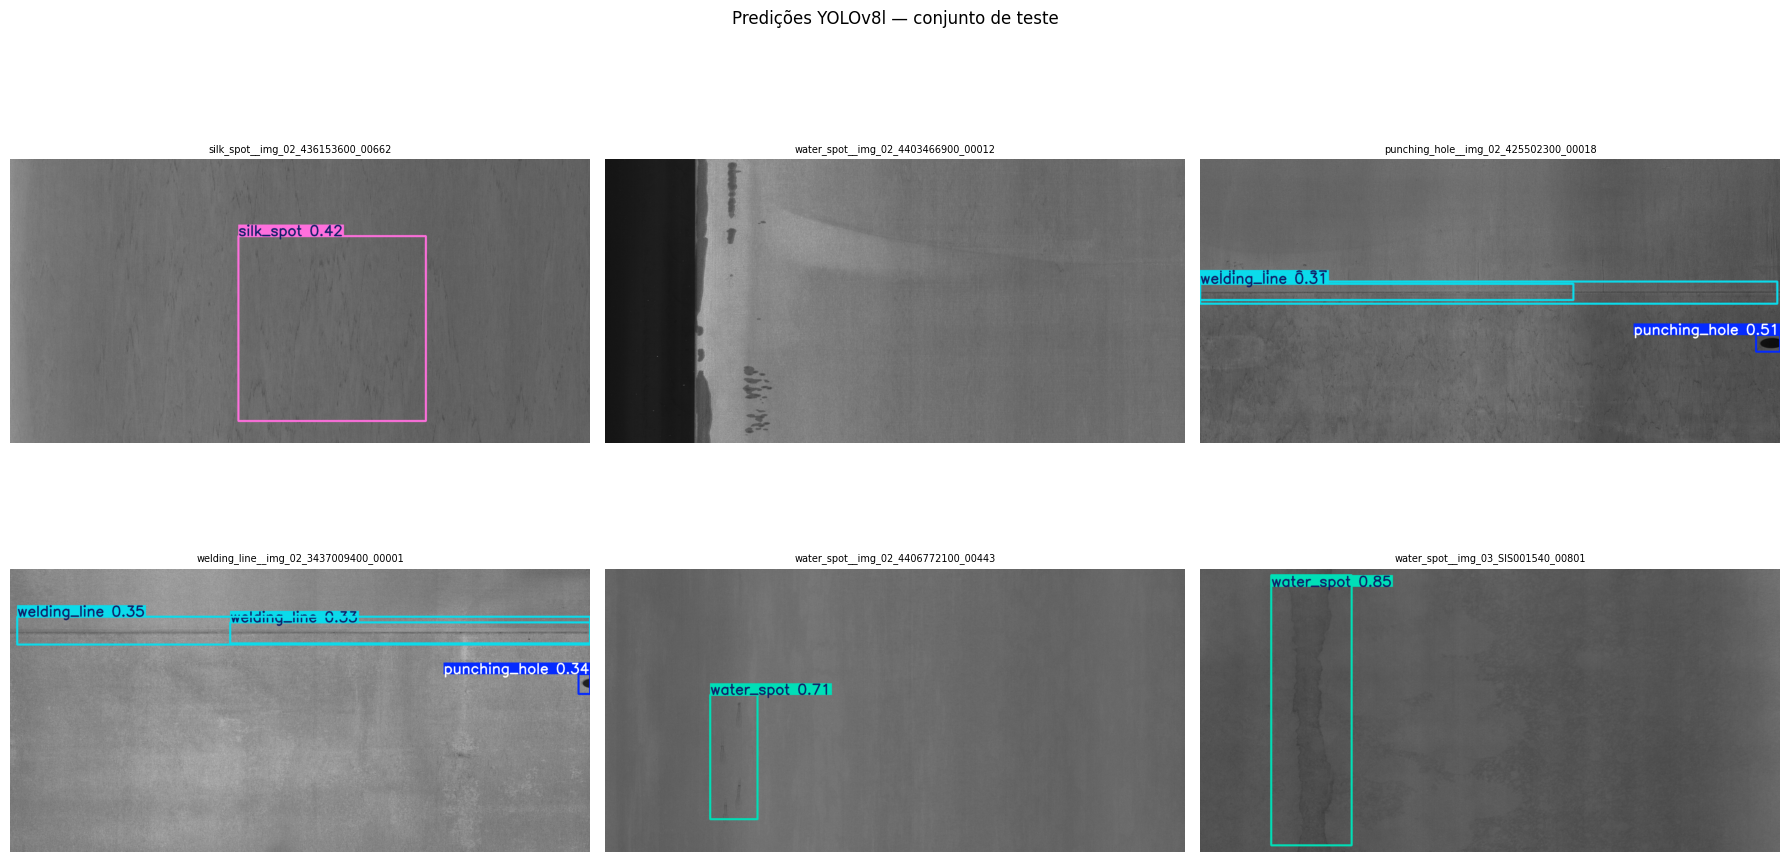

In [16]:
# Visualiza predições no teste
import random as _rnd
test_imgs = list((YOLO_DIR / 'images' / 'test').glob('*.jpg'))
sample    = _rnd.sample(test_imgs, min(6, len(test_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample):
    res = model_best.predict(str(img_path), conf=0.25, imgsz=640, verbose=False)
    annotated = res[0].plot()
    ax.imshow(annotated[:, :, ::-1])
    ax.axis('off')
    ax.set_title(img_path.stem[:45], fontsize=7)

plt.suptitle('Predições YOLOv8l — conjunto de teste', fontsize=12)
plt.tight_layout()
plt.savefig(str(WORK_DIR / 'yolo_predicoes_teste.png'), dpi=120, bbox_inches='tight')
plt.show()


## 11. Modelo Multi-output: Classificação + Localização (PyTorch)

Mesmo paradigma dos notebooks de referência (VGG16, Xception, ResNet152V2 do Jason Kung / Viraj Kadam),
porém com backbone **EfficientNetV2-S** (mais forte e eficiente) e treinamento em PyTorch.

Saídas do modelo:
- `class_out` — softmax sobre 10 classes
- `xmin, ymin, xmax, ymax` — regressão de bbox normalizada [0, 1]


In [17]:
class GC10Dataset(Dataset):
    """
    Dataset que retorna (imagem, (classe_id, xmin_n, ymin_n, xmax_n, ymax_n)).
    Mesmas saídas dos notebooks de referência.
    """
    def __init__(self, dataframe, transform=None, augment_factor=1):
        rows = []
        for _ in range(augment_factor):
            rows.append(dataframe)
        self.df        = pd.concat(rows, ignore_index=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        img = np.array(img)

        if self.transform:
            aug = self.transform(image=img)
            img = aug['image']
        else:
            img = transforms.ToTensor()(Image.fromarray(img))

        label   = int(row['defect_id'])
        bbox    = torch.tensor([
            row['xmin_n'], row['ymin_n'],
            row['xmax_n'], row['ymax_n'],
        ], dtype=torch.float32)
        return img, label, bbox


In [18]:
# Normalização ImageNet (padrão dos notebooks de referência)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Augmentação de treino — equivalente ao AugmentedDataset_A (VGG16 notebook, factor=18)
# Usamos albumentations para augmentação mais rica
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=180, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, p=0.2),
    A.GridDistortion(p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# Augmentation factor por classe (classes raras recebem mais augmentação)
# Inspirado no AugmentedDataset_A com factor=18 do notebook VGG16
CLASS_AUG_FACTOR = {
    'silk_spot':     1,   # classe dominante — sem aug extra
    'water_spot':    3,
    'welding_line':  3,
    'crescent_gap':  4,
    'punching_hole': 4,
    'inclusion':     4,
    'oil_spot':      4,
    'waist_folding': 6,
    'crease':        15,  # rarissima
    'rolled_pit':    18,  # a mais rara — fator equivalente ao notebook VGG16
}

def make_augmented_df(df):
    """Gera DataFrame com linhas replicadas por augmentation factor."""
    parts = []
    for cls, factor in CLASS_AUG_FACTOR.items():
        part = df[df['defect_class'] == cls]
        for _ in range(factor):
            parts.append(part)
    augmented = pd.concat(parts, ignore_index=True)
    return augmented.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Adiciona coordenadas normalizadas ao df (já calculadas no parse_xml)
# Garante que as colunas existem
for col in ['xmin_n', 'ymin_n', 'xmax_n', 'ymax_n']:
    if col not in df.columns:
        df[col] = df[col.replace('_n', '')] / df['width' if 'x' in col else 'height']

train_aug_df = make_augmented_df(train_df)
print(f"Train original : {len(train_df)}")
print(f"Train augmented: {len(train_aug_df)}")
print(f"Val            : {len(val_df)}")
print(f"Test           : {len(test_df)}")


Train original : 1596
Train augmented: 5498
Val            : 342
Test           : 342


/tmp/ipykernel_7356/1746593310.py:13: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),


In [19]:
# DataLoaders
BATCH_SIZE_CLS = 32

train_ds = GC10Dataset(train_aug_df, transform=train_transform)
val_ds   = GC10Dataset(val_df,       transform=val_transform)
test_ds  = GC10Dataset(test_df,      transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_CLS, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE_CLS, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE_CLS, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Batches treino : {len(train_loader)}")
print(f"Batches val    : {len(val_loader)}")
print(f"Batches test   : {len(test_loader)}")


Batches treino : 172
Batches val    : 11
Batches test   : 11


In [20]:
# ── Modelo Multi-output: EfficientNetV2-S + cabeça de classificação + regressão bbox ─
# Mesmo paradigma dos notebooks (VGG16/Xception/ResNet como backbone + Dense heads),
# mas com backbone mais moderno e eficiente

from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

class GC10MultiOutputNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        backbone = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        # Remove head original
        in_feat = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        self.backbone = backbone

        # Cabeça de classificação (softmax sobre 10 classes)
        self.cls_head = nn.Sequential(
            nn.Linear(in_feat, 1024), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(1024, 512),    nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

        # Cabeça de regressão bbox (xmin, ymin, xmax, ymax — normalizados)
        self.bbox_head = nn.Sequential(
            nn.Linear(in_feat, 1024), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(1024, 512),    nn.ReLU(),
            nn.Linear(512, 4),
            nn.Sigmoid(),  # garante saída em [0,1]
        )

    def forward(self, x):
        feat     = self.backbone(x)
        cls_out  = self.cls_head(feat)
        bbox_out = self.bbox_head(feat)
        return cls_out, bbox_out


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_cls = GC10MultiOutputNet(num_classes=len(CLASS_NAMES)).to(DEVICE)
print(f"Modelo em: {DEVICE}")

# Conta parâmetros
total = sum(p.numel() for p in model_cls.parameters())
train_p = sum(p.numel() for p in model_cls.parameters() if p.requires_grad)
print(f"Parâmetros totais    : {total:,}")
print(f"Parâmetros treináveis: {train_p:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /home/cesarmacieira/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:03<00:00, 27.4MB/s]


Modelo em: cuda
Parâmetros totais    : 23,857,758
Parâmetros treináveis: 23,857,758


In [22]:
# ── class_weight para compensar desbalanceamento ──────────────────────────────
# Mesma motivação do notebook Viraj Kadam (upsample da minoria)
# Aqui usamos class_weight no CrossEntropyLoss

class_counts = train_aug_df['defect_id'].value_counts().sort_index()
class_weights = 1.0 / class_counts.values
class_weights = class_weights / class_weights.sum() * len(CLASS_NAMES)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

criterion_cls  = nn.CrossEntropyLoss(weight=class_weights_tensor)
criterion_bbox = nn.SmoothL1Loss()

optimizer = optim.AdamW(model_cls.parameters(), lr=5e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=5,
    factor=0.5,
    min_lr=1e-6
)

print("class_weights:", [f"{w:.3f}" for w in class_weights])


class_weights: ['0.886', '0.954', '0.858', '0.888', '0.936', '1.177', '0.910', '1.487', '1.020', '0.883']


In [23]:
# ── Loop de treino ───────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = cls_correct = cls_total = 0
    for imgs, labels, bboxes in loader:
        imgs, labels, bboxes = imgs.to(DEVICE), labels.to(DEVICE), bboxes.to(DEVICE)
        optimizer.zero_grad()
        cls_out, bbox_out = model(imgs)
        loss_cls  = criterion_cls(cls_out, labels)
        loss_bbox = criterion_bbox(bbox_out, bboxes)
        loss = loss_cls + 0.5 * loss_bbox   # peso bbox = 0.5 (mesmo padrão dos notebooks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss   += loss.item()
        cls_correct  += (cls_out.argmax(1) == labels).sum().item()
        cls_total    += labels.size(0)
    return total_loss / len(loader), cls_correct / cls_total


def eval_epoch(model, loader):
    model.eval()
    total_loss = cls_correct = cls_total = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels, bboxes in loader:
            imgs, labels, bboxes = imgs.to(DEVICE), labels.to(DEVICE), bboxes.to(DEVICE)
            cls_out, bbox_out = model(imgs)
            loss_cls  = criterion_cls(cls_out, labels)
            loss_bbox = criterion_bbox(bbox_out, bboxes)
            loss = loss_cls + 0.5 * loss_bbox
            total_loss  += loss.item()
            preds        = cls_out.argmax(1)
            cls_correct += (preds == labels).sum().item()
            cls_total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), cls_correct / cls_total, all_preds, all_labels


# ── Treinamento — 80 épocas (mais que os 20-40 dos notebooks de referência) ──
EPOCHS = 80
best_val_acc = 0
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_cls, train_loader, optimizer)
    vl_loss, vl_acc, _, _ = eval_epoch(model_cls, val_loader)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model_cls.state_dict(), str(WORK_DIR / 'gc10det_cls_best.pt'))

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'loss {tr_loss:.4f}/{vl_loss:.4f} | '
              f'acc {tr_acc*100:.1f}/{vl_acc*100:.1f}% | '
              f'lr {optimizer.param_groups[0]["lr"]:.2e}')

print(f'\nMelhor val acc: {best_val_acc*100:.2f}%')
print(f'Modelo salvo em: {WORK_DIR / "gc10det_cls_best.pt"}')


Epoch   1/80 | loss 1.6215/0.6453 | acc 44.5/81.0% | lr 5.00e-04
Epoch   5/80 | loss 0.8892/0.4774 | acc 69.6/84.8% | lr 5.00e-04
Epoch  10/80 | loss 0.7394/0.4229 | acc 74.9/86.0% | lr 5.00e-04
Epoch  15/80 | loss 0.5798/0.4218 | acc 80.0/88.0% | lr 2.50e-04
Epoch  20/80 | loss 0.4937/0.4122 | acc 83.2/89.2% | lr 1.25e-04
Epoch  25/80 | loss 0.4088/0.4724 | acc 86.0/90.6% | lr 1.25e-04
Epoch  30/80 | loss 0.3268/0.5966 | acc 89.1/89.5% | lr 6.25e-05
Epoch  35/80 | loss 0.3233/0.6625 | acc 89.3/87.7% | lr 3.13e-05
Epoch  40/80 | loss 0.3062/0.6788 | acc 89.5/89.5% | lr 1.56e-05
Epoch  45/80 | loss 0.3235/0.6835 | acc 88.7/89.2% | lr 7.81e-06
Epoch  50/80 | loss 0.3121/0.6768 | acc 89.7/90.1% | lr 3.91e-06
Epoch  55/80 | loss 0.3098/0.6873 | acc 89.7/88.9% | lr 3.91e-06
Epoch  60/80 | loss 0.2979/0.6794 | acc 90.1/89.8% | lr 1.95e-06
Epoch  65/80 | loss 0.2956/0.6907 | acc 90.2/88.6% | lr 1.00e-06
Epoch  70/80 | loss 0.2978/0.6764 | acc 89.9/89.8% | lr 1.00e-06
Epoch  75/80 | loss 0.291

## 12. Avaliação do modelo multi-output no conjunto de teste

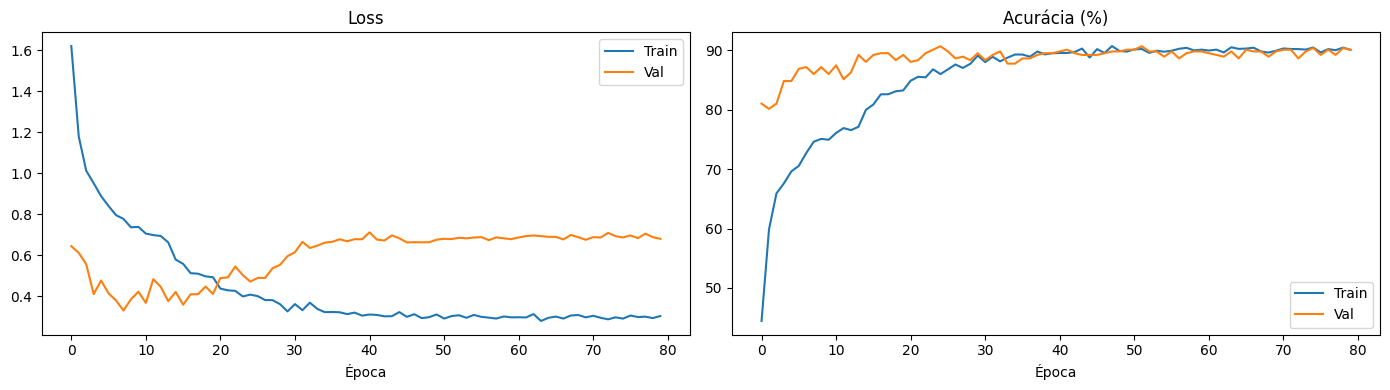

In [24]:
# Carrega melhor checkpoint
model_cls.load_state_dict(torch.load(str(WORK_DIR / 'gc10det_cls_best.pt'), map_location=DEVICE))

# Curvas de treino
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Época'); axes[0].legend()

axes[1].plot([a*100 for a in history['train_acc']], label='Train')
axes[1].plot([a*100 for a in history['val_acc']],   label='Val')
axes[1].set_title('Acurácia (%)'); axes[1].set_xlabel('Época'); axes[1].legend()

plt.tight_layout()
plt.savefig(str(WORK_DIR / 'training_curves.png'), dpi=120)
plt.show()


Acurácia no TESTE: 90.06%

=== Classification Report ===
               precision    recall  f1-score   support

punching_hole       0.85      0.88      0.86        32
 welding_line       0.82      0.80      0.81        40
 crescent_gap       0.84      0.91      0.87        34
   water_spot       1.00      0.95      0.98        43
     oil_spot       0.87      0.87      0.87        30
    silk_spot       0.98      0.99      0.98        97
    inclusion       0.84      0.84      0.84        32
   rolled_pit       1.00      0.50      0.67         4
       crease       0.60      0.75      0.67         8
waist_folding       0.95      0.86      0.90        22

     accuracy                           0.90       342
    macro avg       0.87      0.84      0.85       342
 weighted avg       0.90      0.90      0.90       342



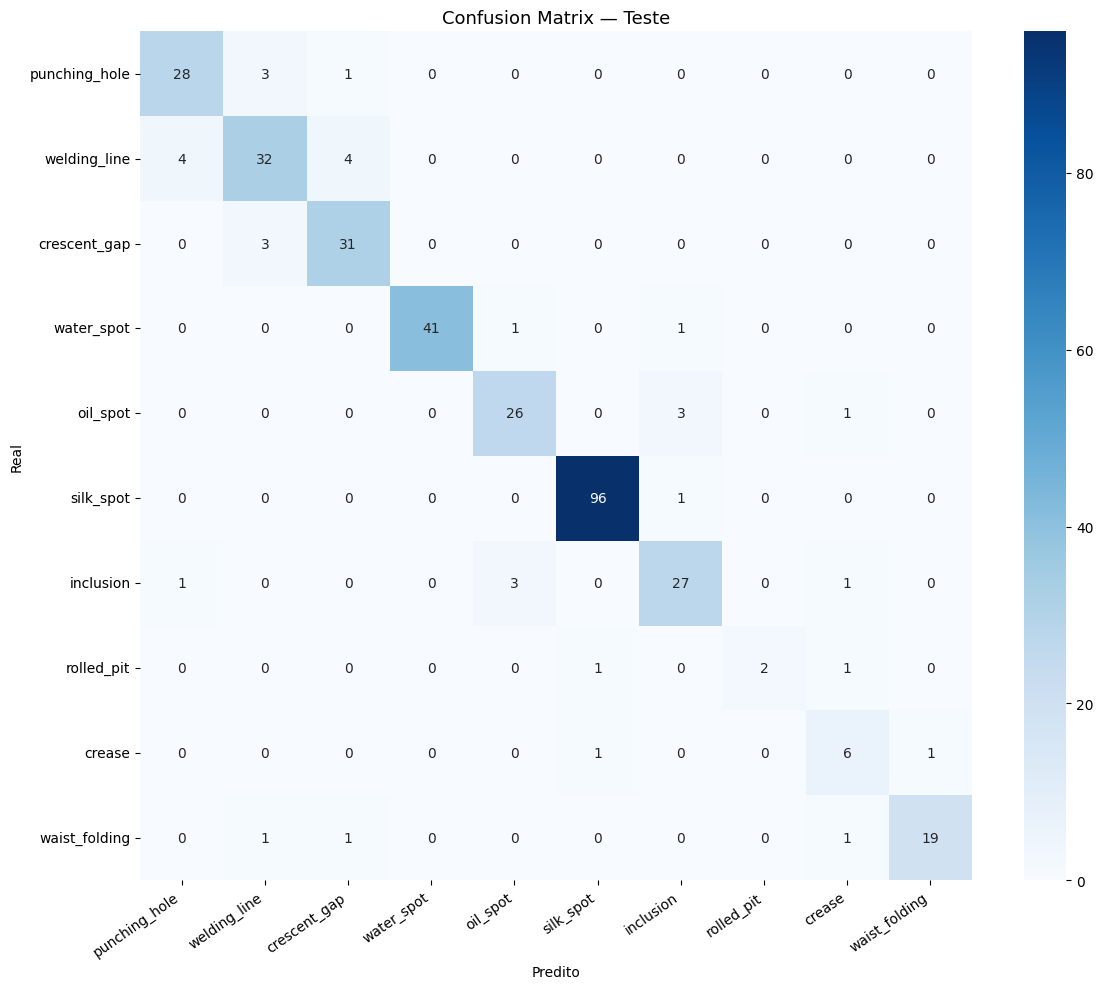


=== Acurácia por classe ===
  punching_hole         :  87.5%  ██████████████████████████
  welding_line          :  80.0%  ████████████████████████
  crescent_gap          :  91.2%  ███████████████████████████
  water_spot            :  95.3%  ████████████████████████████
  oil_spot              :  86.7%  ██████████████████████████
  silk_spot             :  99.0%  █████████████████████████████
  inclusion             :  84.4%  █████████████████████████
  rolled_pit            :  50.0%  ███████████████
  crease                :  75.0%  ██████████████████████
  waist_folding         :  86.4%  █████████████████████████


In [25]:
# Avaliação no teste — classification report (mesmo padrão dos notebooks Jason Kung)
_, test_acc, all_preds, all_labels = eval_epoch(model_cls, test_loader)

print(f'Acurácia no TESTE: {test_acc*100:.2f}%')
print()
print('=== Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Confusion Matrix — Teste', fontsize=13)
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(str(WORK_DIR / 'confusion_matrix.png'), dpi=120)
plt.show()

# Acurácia por classe
print('\n=== Acurácia por classe ===')
for i, cls in enumerate(CLASS_NAMES):
    mask = np.array(all_labels) == i
    if mask.sum() > 0:
        acc_i = (np.array(all_preds)[mask] == i).mean()
        bar   = '█' * int(acc_i * 30)
        print(f'  {cls:<22}: {acc_i*100:5.1f}%  {bar}')


## 13. Exportação para o app Streamlit

In [26]:
APP_DIR = WORK_DIR  # mesmo diretório onde está app_gc10det.py

# 1. Pesos YOLOv8
yolo_best = WORK_DIR / 'runs' / 'yolov8l_gc10det4' / 'weights' / 'best.pt'
if yolo_best.exists():
    shutil.copy2(yolo_best, APP_DIR / 'yolo_detector.pt')
    print(f'yolo_detector.pt  copiado  ({yolo_best.stat().st_size/1e6:.1f} MB)')
else:
    print('AVISO: yolo_detector.pt não encontrado em', yolo_best)

# 2. Pesos modelo classificação
cls_src = WORK_DIR / 'gc10det_cls_best.pt'
if cls_src.exists():
    shutil.copy2(cls_src, APP_DIR / 'gc10det_cls.pt')
    print(f'gc10det_cls.pt    copiado  ({cls_src.stat().st_size/1e6:.1f} MB)')

# 3. Metadados
try:
    best_map_val = float(metrics.box.map50)
except Exception:
    best_map_val = 0.0

meta = {
    'model':          'yolov8l',
    'backbone':       'YOLOv8l',
    'best_map':       best_map_val,
    'best_cls_acc':   best_val_acc,
    'num_classes':    len(CLASS_NAMES),
    'class_names':    CLASS_NAMES,
    'class_names_pt': CLASS_PT,
    'dataset':        'GC10-DET',
    'imgsz':          640,
    'split':          'stratified 70/15/15',
}
meta_path = APP_DIR / 'detection_metadata.json'
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print('detection_metadata.json salvo.')

# 4. Checklist final
print('\n=== Arquivos para o app ===')
for fname in ['app_gc10det.py', 'yolo_detector.pt', 'gc10det_cls.pt', 'detection_metadata.json']:
    p = APP_DIR / fname
    status = f'OK  {p.stat().st_size/1e6:.1f} MB' if p.exists() else '--  não encontrado'
    print(f'  {status:<20} {fname}')

print('\nPara rodar o app:')
print(f'  cd "{APP_DIR}"')
print(f'  streamlit run app_gc10det.py')


yolo_detector.pt  copiado  (87.6 MB)
gc10det_cls.pt    copiado  (96.4 MB)
detection_metadata.json salvo.

=== Arquivos para o app ===
  OK  0.0 MB           app_gc10det.py
  OK  87.6 MB          yolo_detector.pt
  OK  96.4 MB          gc10det_cls.pt
  OK  0.0 MB           detection_metadata.json

Para rodar o app:
  cd "/mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/defeitos-superficie"
  streamlit run app_gc10det.py
